# **Informe de diagnósitco y enfoque analítico (EDA COVID-19)**

## **1. Diagnóstico de la estructura y tipos de datos (.info())**

### **1.1 Librerías**

In [45]:
# Importación de librerías necesarias para análisis y visualización de datos
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np 
import os
import scipy.stats as stats
import statsmodels.formula.api as smf


El inicio del notebook se enfoca en librerías estándar para análisis de datos (pandas, numpy) y visualización (matplotlib, seaborn). La inclusión de scipy.stats y statsmodels nos permite avanzar hacia el modelado estadístico y pruebas de hipótesis.

### **1.2 Base de datos de la histórica de todos los estados**

In [46]:
# Base de datos de todos los estados
datos_estados = "../data/all-states-history.csv"

# Carga del dataset
df_states= pd.read_csv(datos_estados)
df_states.head()

,date,state,death,deathConfirmed,deathIncrease,deathProbable,hospitalized,hospitalizedCumulative,hospitalizedCurrently,hospitalizedIncrease,...,totalTestResults,totalTestResultsIncrease,totalTestsAntibody,totalTestsAntigen,totalTestsPeopleAntibody,totalTestsPeopleAntigen,totalTestsPeopleViral,totalTestsPeopleViralIncrease,totalTestsViral,totalTestsViralIncrease
0,2021-03-07,AK,305.0,NaN,0,NaN,1293.0,1293.0,33.0,0,...,1731628.0,0,NaN,NaN,NaN,NaN,NaN,0,1731628.0,0
1,2021-03-07,AL,10148.0,7963.0,-1,2185.0,45976.0,45976.0,494.0,0,...,2323788.0,2347,NaN,NaN,119757.0,NaN,2323788.0,2347,NaN,0
2,2021-03-07,AR,5319.0,4308.0,22,1011.0,14926.0,14926.0,335.0,11,...,2736442.0,3380,NaN,NaN,NaN,481311.0,NaN,0,2736442.0,3380
3,2021-03-07,AS,0.0,NaN,0,NaN,NaN,NaN,NaN,0,...,2140.0,0,NaN,NaN,NaN,NaN,NaN,0,2140.0,0
4,2021-03-07,AZ,16328.0,14403.0,5,1925.0,57907.0,57907.0,963.0,44,...,7908105.0,45110,580569.0,NaN,444089.0,NaN,3842945.0,14856,7908105.0,45110


In [47]:
df_states.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20780 entries, 0 to 20779
Data columns (total 41 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   date                              20780 non-null  object 
 1   state                             20780 non-null  object 
 2   death                             19930 non-null  float64
 3   deathConfirmed                    9422 non-null   float64
 4   deathIncrease                     20780 non-null  int64  
 5   deathProbable                     7593 non-null   float64
 6   hospitalized                      12382 non-null  float64
 7   hospitalizedCumulative            12382 non-null  float64
 8   hospitalizedCurrently             17339 non-null  float64
 9   hospitalizedIncrease              20780 non-null  int64  
 10  inIcuCumulative                   3789 non-null   float64
 11  inIcuCurrently                    11636 non-null  float64
 12  nega

In [48]:
print(df_states.describe())

              death  deathConfirmed  deathIncrease  deathProbable  \
count  19930.000000     9422.000000   20780.000000    7593.000000   
mean    3682.216859     3770.182764      24.790712     417.291321   
std     6281.366321     4157.640633      60.162742     537.625982   
min        0.000000        0.000000    -201.000000       0.000000   
25%      161.250000      607.000000       0.000000      79.000000   
50%     1108.000000     2409.500000       6.000000     216.000000   
75%     4387.500000     5462.000000      24.000000     460.000000   
max    54124.000000    21177.000000    2559.000000    2594.000000   

       hospitalized  hospitalizedCumulative  hospitalizedCurrently  \
count  12382.000000            12382.000000           17339.000000   
mean    9262.762478             9262.762478            1190.576965   
std    12620.544081            12620.544081            2060.041207   
min        1.000000                1.000000               0.000000   
25%      985.250000         

### **1.3 Base de datos de los datos nacionales**

In [49]:
#Base de datos nivel nacional
datos_nacional = "../data/national-history.csv"

#Carga del dataset nivel nacional
df_national = pd.read_csv(datos_nacional)
df2=pd.read_csv(datos_nacional)
df_national.head()


,date,death,deathIncrease,inIcuCumulative,inIcuCurrently,hospitalizedIncrease,hospitalizedCurrently,hospitalizedCumulative,negative,negativeIncrease,onVentilatorCumulative,onVentilatorCurrently,positive,positiveIncrease,states,totalTestResults,totalTestResultsIncrease
0,2021-03-07,515151.0,842,45475.0,8134.0,726,40199.0,776361.0,74582825.0,131835,4281.0,2802.0,28756489.0,41835,56,363825123,1170059
1,2021-03-06,514309.0,1680,45453.0,8409.0,503,41401.0,775635.0,74450990.0,143835,4280.0,2811.0,28714654.0,60015,56,362655064,1430992
2,2021-03-05,512629.0,2221,45373.0,8634.0,2781,42541.0,775132.0,74307155.0,271917,4275.0,2889.0,28654639.0,68787,56,361224072,1744417
3,2021-03-04,510408.0,1743,45293.0,8970.0,1530,44172.0,772351.0,74035238.0,177957,4267.0,2973.0,28585852.0,65487,56,359479655,1590984
4,2021-03-03,508665.0,2449,45214.0,9359.0,2172,45462.0,770821.0,73857281.0,267001,4260.0,3094.0,28520365.0,66836,56,357888671,1406795


In [50]:
df_national.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date                      420 non-null    object 
 1   death                     392 non-null    float64
 2   deathIncrease             420 non-null    int64  
 3   inIcuCumulative           348 non-null    float64
 4   inIcuCurrently            347 non-null    float64
 5   hospitalizedIncrease      420 non-null    int64  
 6   hospitalizedCurrently     356 non-null    float64
 7   hospitalizedCumulative    369 non-null    float64
 8   negative                  372 non-null    float64
 9   negativeIncrease          420 non-null    int64  
 10  onVentilatorCumulative    341 non-null    float64
 11  onVentilatorCurrently     348 non-null    float64
 12  positive                  419 non-null    float64
 13  positiveIncrease          420 non-null    int64  
 14  states    

In [51]:
print(df_national.describe())

               death  deathIncrease  inIcuCumulative  inIcuCurrently  \
count     392.000000     420.000000       348.000000      347.000000   
mean   187210.668367    1226.550000     21059.344828    12059.227666   
std    142331.657380    1070.129644     13572.638376     5668.415483   
min         0.000000       0.000000        74.000000     1299.000000   
25%     86911.750000     439.750000      9900.250000     7495.500000   
50%    169118.500000    1016.000000     18797.500000    10114.000000   
75%    258912.250000    1642.500000     32998.500000    15596.500000   
max    515151.000000    5427.000000     45475.000000    23912.000000   

       hospitalizedIncrease  hospitalizedCurrently  hospitalizedCumulative  \
count            420.000000             356.000000              369.000000   
mean            1848.478571           57987.117978           310817.140921   
std             1708.460481           31898.555998           235557.870159   
min            -2858.000000            

Decidimos hacer una segmentación en dos dimensiones de análisis.

Al cargar las dos fuentes principales de datos (all-states-history.csv y national-history.csv), se observa una diferencia crítica en las dimensiones y los propósitos analíticos:
1. **df_states (Datos por Estado)**: Cuenta con 20,780 registros y 41 columnas. Es un conjunto de datos tridimensional (Fecha x Estado x Métricas). Los tipos de datos se dividen en su mayoría en valores decimales (float64 para métricas acumuladas debido a la presencia de nulos) y enteros (int64 para los incrementos diarios).
2. **df_national (Datos Nacionales)**: Cuenta con 420 registros y 17 columnas. Es una serie temporal limpia y consolidada a nivel país día a día.

## **2. Limpieza y normalización de datos**

### **2.1. Cambio de formato**

In [52]:
# Cambiamos a formato fecha las columnas con este tipo de dato

df_states['date'] = pd.to_datetime(df_states['date'])

# Cambio formato numeros

cols_float = [
    'death', 'deathConfirmed', 'deathProbable', 'hospitalized', 
    'hospitalizedCumulative', 'hospitalizedCurrently', 
    'inIcuCumulative', 'inIcuCurrently', 'negative'
]
df_states[cols_float] = df_states[cols_float].astype(float)

cols_int = ['deathIncrease', 'hospitalizedIncrease', 'negativeIncrease']
df_states[cols_int] = df_states[cols_int].astype(int)




In [53]:
# Cambiamos a formato fecha las columnas con este tipo de dato

df_national['date'] = pd.to_datetime(df_national['date'])

#Cambio formato numeros
cols_float = [
    'death', 'inIcuCumulative', 'inIcuCurrently', 'hospitalizedCurrently', 
    'hospitalizedCumulative', 'negative', 'onVentilatorCumulative', 
    'onVentilatorCurrently', 'positive'
]
df_national[cols_float] = df_national[cols_float].astype(float)
cols_int = [
    'deathIncrease', 'hospitalizedIncrease', 'negativeIncrease', 
    'positiveIncrease', 'states', 'totalTestResults', 'totalTestResultsIncrease'
]
df_national[cols_int] = df_national[cols_int].astype(int)

La columna "date" es leída inicialmente como tipo "object". El primer paso obligatorio de limpieza consiste en transformar esta columna al tipo nativo de tiempo, para permitir la segmentación correcta por meses o semanas epidemiológicas.

### **2.2 Duplicados**

#### **2.2.1 Duplicados estados**

In [54]:
# Cuenta el total de filas que están idénticas y repetidas en todo el dataset.
print(df_states.duplicated().sum())

# Muestra cuáles son esas filas duplicadas para revisar visualmente el error antes de borrarlas.
print(df_states[df_states.duplicated(keep=False)])


0
Empty DataFrame
Columns: [date, state, death, deathConfirmed, deathIncrease, deathProbable, hospitalized, hospitalizedCumulative, hospitalizedCurrently, hospitalizedIncrease, inIcuCumulative, inIcuCurrently, negative, negativeIncrease, negativeTestsAntibody, negativeTestsPeopleAntibody, negativeTestsViral, onVentilatorCumulative, onVentilatorCurrently, positive, positiveCasesViral, positiveIncrease, positiveScore, positiveTestsAntibody, positiveTestsAntigen, positiveTestsPeopleAntibody, positiveTestsPeopleAntigen, positiveTestsViral, recovered, totalTestEncountersViral, totalTestEncountersViralIncrease, totalTestResults, totalTestResultsIncrease, totalTestsAntibody, totalTestsAntigen, totalTestsPeopleAntibody, totalTestsPeopleAntigen, totalTestsPeopleViral, totalTestsPeopleViralIncrease, totalTestsViral, totalTestsViralIncrease]
Index: []

[0 rows x 41 columns]


In [55]:
# Elimina las filas duplicadas manteniendo solo la primera aparición para no adulterar el análisis estadístico.
df_states = df_states.drop_duplicates()

#### **2.2.2 Duplicados nacional**

In [56]:
# Cuenta el total de filas que están idénticas y repetidas en todo el dataset.
print(df_national.duplicated().sum())

# Muestra cuáles son esas filas duplicadas para revisar visualmente el error antes de borrarlas.
print(df_national[df_national.duplicated(keep=False)])

0
Empty DataFrame
Columns: [date, death, deathIncrease, inIcuCumulative, inIcuCurrently, hospitalizedIncrease, hospitalizedCurrently, hospitalizedCumulative, negative, negativeIncrease, onVentilatorCumulative, onVentilatorCurrently, positive, positiveIncrease, states, totalTestResults, totalTestResultsIncrease]
Index: []


In [57]:
# Elimina las filas duplicadas manteniendo solo la primera aparición para no adulterar el análisis estadístico.
df_national = df_national.drop_duplicates()

### **2.3 Valores nulos en nuestra base de datos**

#### **2.3.1 Valores nulos estados**

In [58]:
# Muestra cuántos valores nulos hay en cada columna para identificar qué datos están incompletos.
print(df_states.isnull().sum())

# Calcula el porcentaje de nulos por columna para evaluar si vale la pena conservar o eliminar una variable.
print((df_states.isnull().sum() / len(df_states)) * 100)

date                                    0
state                                   0
death                                 850
deathConfirmed                      11358
deathIncrease                           0
deathProbable                       13187
hospitalized                         8398
hospitalizedCumulative               8398
hospitalizedCurrently                3441
hospitalizedIncrease                    0
inIcuCumulative                     16991
inIcuCurrently                       9144
negative                             7490
negativeIncrease                        0
negativeTestsAntibody               19322
negativeTestsPeopleAntibody         19808
negativeTestsViral                  15756
onVentilatorCumulative              19490
onVentilatorCurrently               11654
positive                              188
positiveCasesViral                   6534
positiveIncrease                        0
positiveScore                           0
positiveTestsAntibody             

#### **2.3.2 Valores nulos Nacional**

In [59]:
# Muestra cuántos valores nulos hay en cada columna para identificar qué datos están incompletos.
print(df_national.isnull().sum())

# Calcula el porcentaje de nulos por columna para evaluar si vale la pena conservar o eliminar una variable.
print((df_national.isnull().sum() / len(df_national)) * 100)

date                         0
death                       28
deathIncrease                0
inIcuCumulative             72
inIcuCurrently              73
hospitalizedIncrease         0
hospitalizedCurrently       64
hospitalizedCumulative      51
negative                    48
negativeIncrease             0
onVentilatorCumulative      79
onVentilatorCurrently       72
positive                     1
positiveIncrease             0
states                       0
totalTestResults             0
totalTestResultsIncrease     0
dtype: int64
date                         0.000000
death                        6.666667
deathIncrease                0.000000
inIcuCumulative             17.142857
inIcuCurrently              17.380952
hospitalizedIncrease         0.000000
hospitalizedCurrently       15.238095
hospitalizedCumulative      12.142857
negative                    11.428571
negativeIncrease             0.000000
onVentilatorCumulative      18.809524
onVentilatorCurrently       17.142857
posi

La salida de .info() revela el comportamiento del reporte de datos públicos durante la pandemia: 
1. Las variables genéricas acumuladas como "death" (19,930 valores no nulos) o "positive" (20,592 valores no nulos) están prácticamente completas en comparación con el total de 20,780 filas.
2. Las variables específicas sufren de una severa ausencia de datos: por ejemplo, "deathConfirmed" solo tiene 9,422 registros, "deathProbable" 7,593, y "negativeTestsPeopleAntibody" apenas cuenta con 972 registros.

No todos los estados federados recopilaban o desglosaban la información con los mismos criterios. Algunos estados no informaron de pruebas de antígenos o anticuerpos específicas, o no diferenciaban de forma retroactiva las muertes probables de las confirmadas. Por lo tanto, se justifica centrar los análisis e hipótesis en las variables globales (death, positive, totalTestResults) para no perder poder estadístico ni sesgar la muestra territorial.

### **2.4. Cambiamos los nulos por 0**

In [60]:
# Reemplaza todos los NaN que existan en cualquier parte de la tabla por 0

df_states = df_states.fillna(0)

df_national = df_national.fillna(0)

### **2.5 Creación de columnas**

In [61]:
columnas_sumar = [
    "totalTestEncountersViral", "totalTestEncountersViralIncrease", 
    "totalTestResults", "totalTestResultsIncrease", 
    "totalTestsAntibody", "totalTestsAntigen", 
    "totalTestsPeopleAntibody", "totalTestsPeopleAntigen", 
    "totalTestsPeopleViral", "totalTestsPeopleViralIncrease", 
    "totalTestsViral", "totalTestsViralIncrease"
]

# 2. Creamos la nueva columna con el resultado del sumatorio para ver los test totales
df_states['totalGlobalTests'] = df_states[columnas_sumar].sum(axis=1)

df_states.head()

,date,state,death,deathConfirmed,deathIncrease,deathProbable,hospitalized,hospitalizedCumulative,hospitalizedCurrently,hospitalizedIncrease,...,totalTestResultsIncrease,totalTestsAntibody,totalTestsAntigen,totalTestsPeopleAntibody,totalTestsPeopleAntigen,totalTestsPeopleViral,totalTestsPeopleViralIncrease,totalTestsViral,totalTestsViralIncrease,totalGlobalTests
0,2021-03-07,AK,305.0,0.0,0,0.0,1293.0,1293.0,33.0,0,...,0,0.0,0.0,0.0,0.0,0.0,0,1731628.0,0,3463256.0
1,2021-03-07,AL,10148.0,7963.0,-1,2185.0,45976.0,45976.0,494.0,0,...,2347,0.0,0.0,119757.0,0.0,2323788.0,2347,0.0,0,4772027.0
2,2021-03-07,AR,5319.0,4308.0,22,1011.0,14926.0,14926.0,335.0,11,...,3380,0.0,0.0,0.0,481311.0,0.0,0,2736442.0,3380,5960955.0
3,2021-03-07,AS,0.0,0.0,0,0.0,0.0,0.0,0.0,0,...,0,0.0,0.0,0.0,0.0,0.0,0,2140.0,0,4280.0
4,2021-03-07,AZ,16328.0,14403.0,5,1925.0,57907.0,57907.0,963.0,44,...,45110,580569.0,0.0,444089.0,0.0,3842945.0,14856,7908105.0,45110,20788889.0


### **2.6 Comprobacion outliers** 

In [62]:
#Comprobamos cuáles son los 5 estados que más aparecen en el dataset para entender mejor la distribución de los datos y enfocarnos en los estados con mayor cantidad de registros para análisis posteriores.
top_5_frecuentes = df_states['state'].value_counts().head(5).index.tolist()

print(f"Los 5 estados con más registros en el dataset son: {top_5_frecuentes}")



Los 5 estados con más registros en el dataset son: ['WA', 'MA', 'VA', 'FL', 'NJ']


#### **2.6.1 Normalidad**

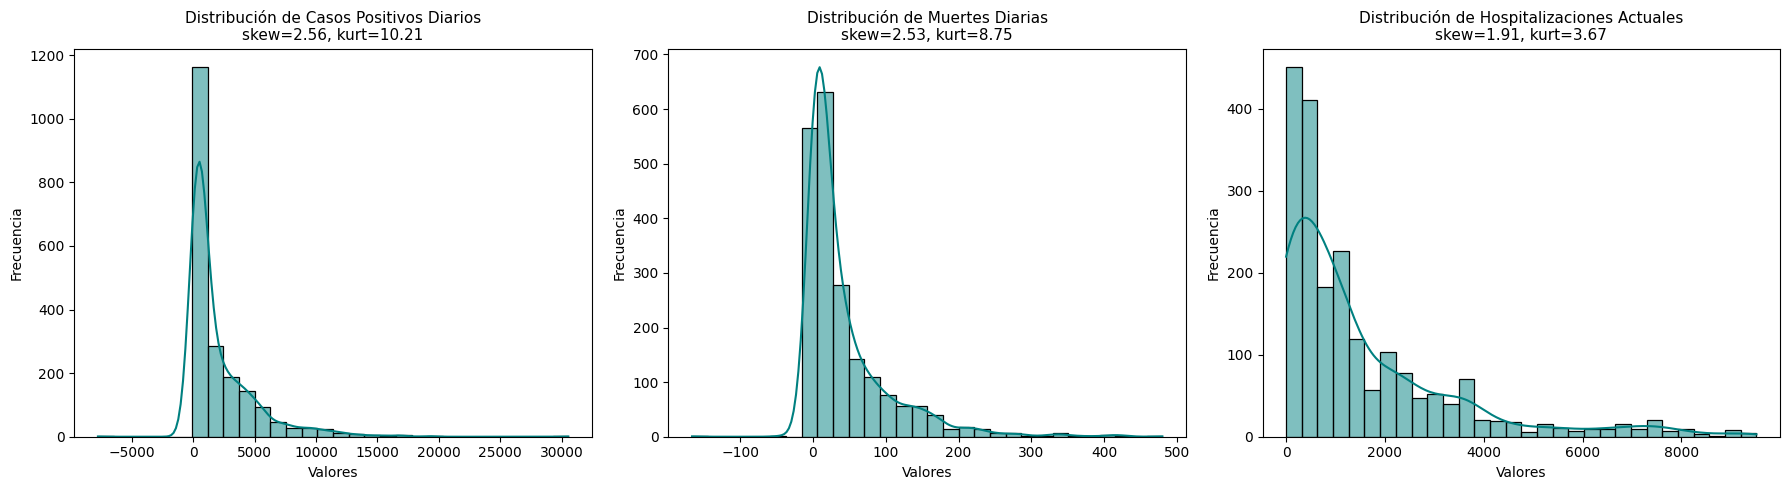

In [63]:
df_top5 = df_states[df_states["state"].isin(top_5_frecuentes)]

# 3. Definir las variables reales del proyecto y sus títulos correspondientes
variables_states1 = [
    "positiveIncrease",
    "deathIncrease",
    "hospitalizedCurrently",
]
titulos = [
    "Distribución de Casos Positivos Diarios",
    "Distribución de Muertes Diarias",
    "Distribución de Hospitalizaciones Actuales",
]

# Creamos la figura con una cuadrícula de 1 fila x 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 4. Iterar sobre tus columnas reales usando df_top5 para los cálculos
for ax, columna, titulo in zip(axes, variables_states1, titulos):

    # Aquí usamos df_top5 para sacar los datos reales de las columnas
    datos_limpios = df_top5[columna].dropna()

    if len(datos_limpios) > 0:
        # Dibujar el histograma con la curva de densidad (KDE)
        sns.histplot(datos_limpios, kde=True, ax=ax, color="teal", bins=30)

        # Calcular asimetría (skew) y curtosis reales
        asimetria_real = stats.skew(datos_limpios)
        curtosis_real = stats.kurtosis(datos_limpios)

        # Configurar título dinámico con los valores estadísticos reales de tu dataset
        ax.set_title(
            f"{titulo}\nskew={asimetria_real:.2f}, kurt={curtosis_real:.2f}",
            fontsize=11,
        )
        ax.set_xlabel("Valores")
        ax.set_ylabel("Frecuencia")
    else:
        ax.set_title(f"{titulo}\n(Sin datos disponibles)")

plt.tight_layout()
plt.show()

#### **2.6.2 Boxplot del incremento de positivos**

Text(0.5, 0, 'Total paid per trip')

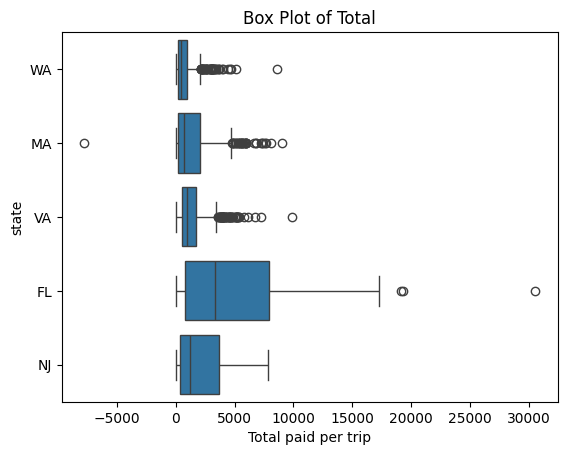

In [64]:

# Create a box plot
g = sns.boxplot(
    data=df_states,
    x="positiveIncrease",
    y="state",
    order=top_5_frecuentes)
# Add a title and change xlabel
g.set_title('Box Plot of Total')
g.set_xlabel('Total paid per trip')

#### **2.6.3 Boxplot del incremento de muertes**

Text(0.5, 0, 'Total paid per trip')

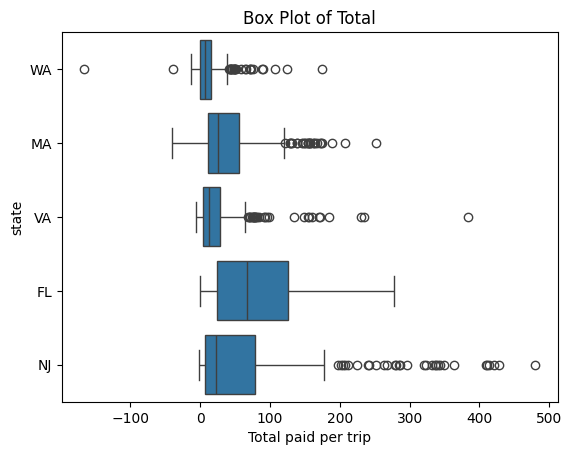

In [65]:
# Create a box plot
g = sns.boxplot(
    data=df_states,
    x="deathIncrease",
    y="state",
    order=top_5_frecuentes)
# Add a title and change xlabel
g.set_title('Box Plot of Total')
g.set_xlabel('Total paid per trip')

#### **2.6.4 Boxplot de los hospitalizados actuales**

Text(0.5, 0, 'Total paid per trip')

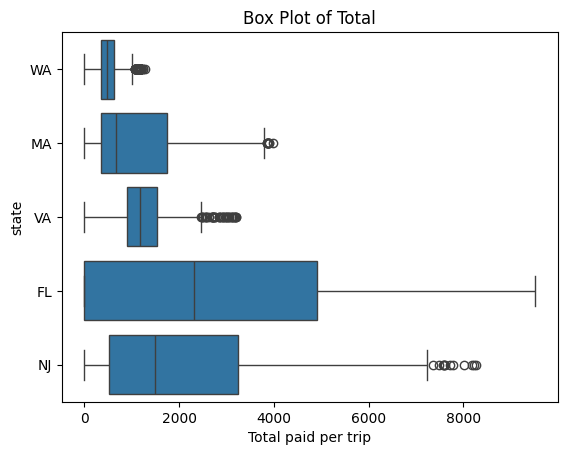

In [66]:
# Create a box plot
g = sns.boxplot(
    data=df_states,
    x="hospitalizedCurrently",
    y="state",
    order=top_5_frecuentes)
# Add a title and change xlabel
g.set_title('Box Plot of Total')
g.set_xlabel('Total paid per trip')

A partir de la descripción estadística, al cierre del periodo registrado:
1. Los casos positivos acumulados escalaron hasta un máximo de 28,756,489 casos en el país. 
2. El promedio diario de muertes acumuladas a lo largo de la serie fue de 18,210, alcanzando un pico máximo de 515,151 fallecidos. El incremento diario promedio se situó en 1,226 muertes, con una jornada crítica donde se reportaron 5,427 decesos en un solo día.
3. El promedio de personas hospitalizadas simultáneamente fue de 57,987, alcanzando un pico máximo de 132,474 pacientes hospitalizados de forma concurrente. El uso de camas de UCI promedió 12,059 pacientes, con un máximo de 23,912 personas en cuidados intensivos. 

#### **2.6.5 Correlacion**

In [67]:
# Calcula la correlación directamente
correlacion = df_states['hospitalizedCurrently'].corr(df_states['deathIncrease'])

if correlacion < 0.05:

    print("Resultado: La relación es estadísticamente significativa (p < 0.05).")

else:

    print("Resultado: No hay evidencia suficiente para afirmar una relación significativa.")

Resultado: No hay evidencia suficiente para afirmar una relación significativa.


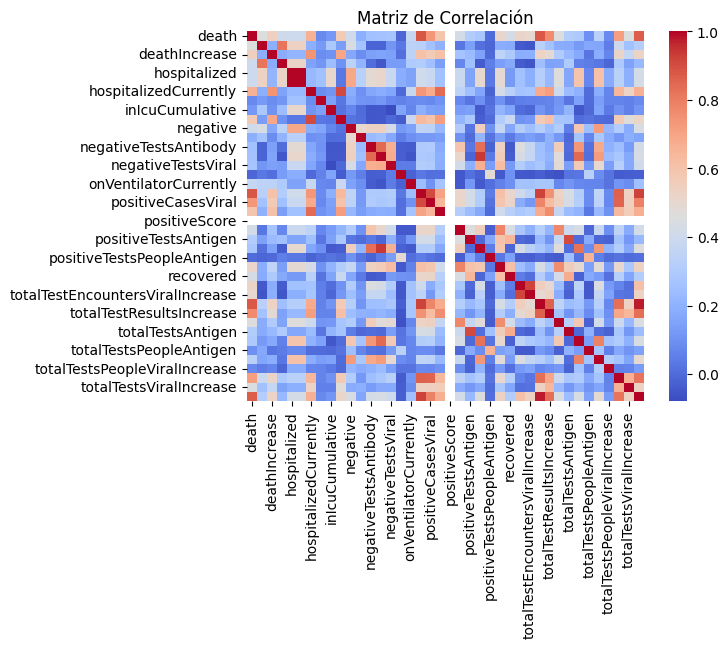

In [68]:
sns.heatmap(df_states.corr(numeric_only=True), annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación')
plt.show()

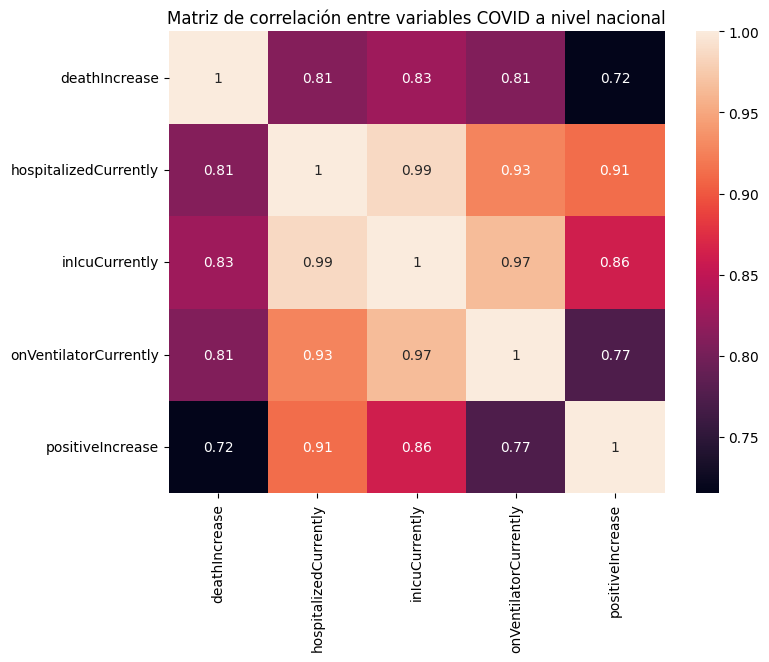

In [84]:
#Seleccionamos estas 5 columnas
vars_corr = df_national[
     [
        'deathIncrease',
        'hospitalizedCurrently',
        'inIcuCurrently',
        'onVentilatorCurrently',
        'positiveIncrease'
     ]
]
#La función corr calcula el coeficiente de correlación entre cada par de variables.
corr_matrix = vars_corr.corr()
corr_matrix
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True)
plt.title("Matriz de correlación entre variables COVID a nivel nacional")
plt.show()

En el gráfico se puede observar que:
Las muertes diarias tienen una correlación positiva con hospitalizaciones, UCI y uso de ventiladores. La correlación con los casos positivos diarios también existe, aunque suele ser más moderada. Las variables hospitalarias están fuertemente relacionadas entre sí, lo cual es esperable.

### **2.6.6 Gráficos de violín**

A diferencia de los boxplots, el gráfico de violín nos permite ver no solo los cuartiles y la mediana, sino también la densidad de probabilidad de los datos (la forma de la curva de distribución). Esto es clave para entender el comportamiento de la pandemia en los territorios. 

C:\Users\Usuario\AppData\Local\Temp\ipykernel_28528\2816362773.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.violinplot(


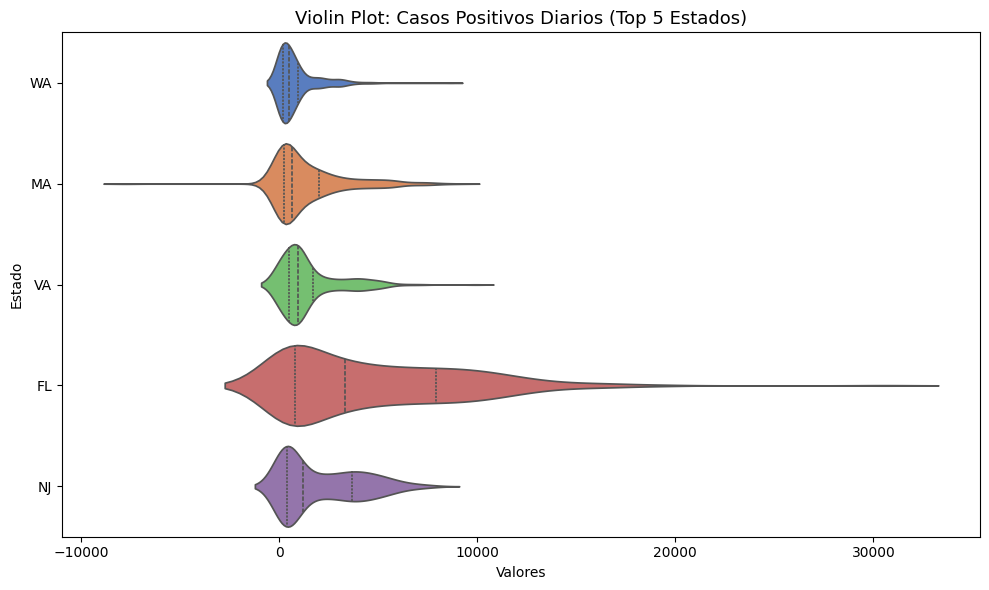

C:\Users\Usuario\AppData\Local\Temp\ipykernel_28528\2816362773.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.violinplot(


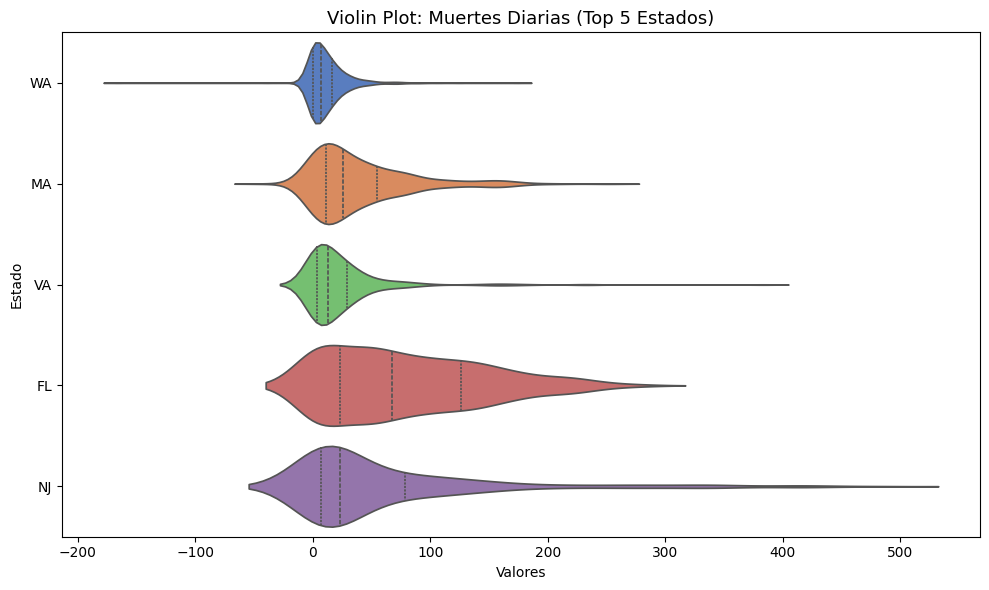

C:\Users\Usuario\AppData\Local\Temp\ipykernel_28528\2816362773.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.violinplot(


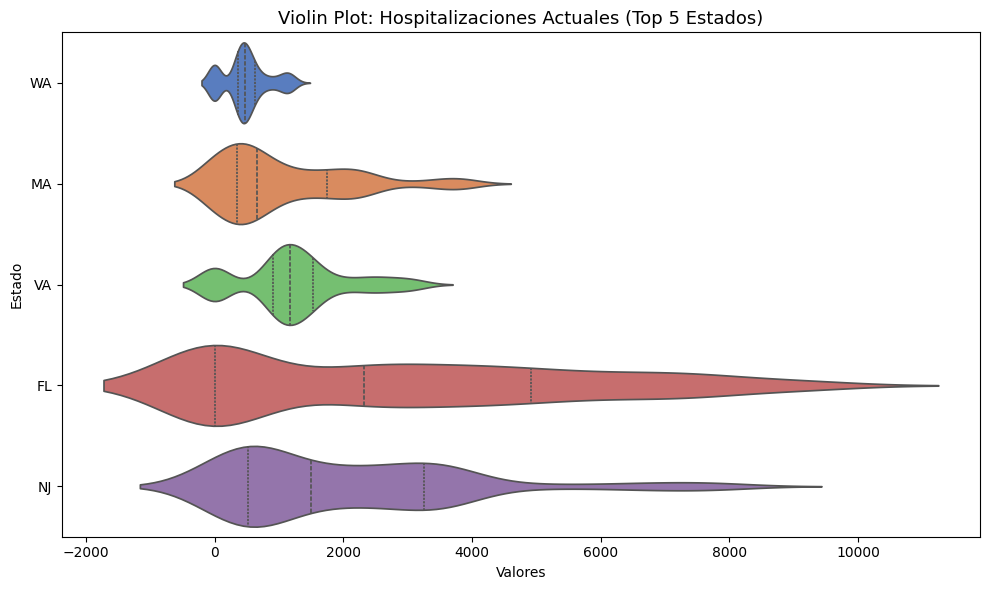

In [69]:
titulos = [
    "Violin Plot: Casos Positivos Diarios",
    "Violin Plot: Muertes Diarias",
    "Violin Plot: Hospitalizaciones Actuales",
]

# Generamos los 3 gráficos en formato vertical para comparar mejor las siluetas
for columna, titulo in zip(variables_states1, titulos):
    plt.figure(figsize=(10, 6))

    # El gráfico de violín se configura igual que el boxplot
    g = sns.violinplot(
        data=df_top5,
        x=columna,
        y="state",
        order=top_5_frecuentes,
        palette="muted",
        inner="quartile",  # Dibuja las líneas de los cuartiles dentro del violín
    )

    g.set_title(f"{titulo} (Top 5 Estados)", fontsize=13)
    g.set_xlabel("Valores")
    g.set_ylabel("Estado")

    plt.tight_layout()
    plt.show()

La distribución de los **casos positivos diarios (positiveIncrease)** muestra una base ancha cerca del 0 y un cuello extremadamente alargado: esto indica que los estados mantuvieron niveles de contagio diario relativamente bajos o controlados, con picos aislados descomunales. Algunos estados (California, Texas, Florida) presentan violines con dos o tres ensanchamientos claros: representan las olas de la pandemia.

El comportamiento del violín de **fallecimientos diarios (deathIncrease)** aporta información crítica. Al comparar el violín de hospitalizaciones con fallecidos, se nota el desfase temporal o "efecto rezago": la densidad de fallecidos tarda semanas en ensancharse después de que el violín de contagios se dispara. Vemos la presencia de anomalías en la base del violín, pues el ensanchamiento por debajo de 0 confirma lo que detectamos en el análisis descriptivo: reportes con valores negativos debido a las correcciones y ajustes de datos de las auditorías estatales.

El gráfico de violín para las **hospitalizaciones activas (hospitalizedCurrently)** revela el nivel de estrés hospitalario: estados con menor población o curvas más aplanadas muestran violines "achatados" y concentrados en la parte inferior, lo que significa que los sistemas de salud operaban al límite. En los estados que fueron epicentros de las olas (Nueva York al principio, después Texas), el violín se ensancha en valores medios y altos. Esto demuestra que la alta ocupación hospitalaria es una situación sostenida durante semanas, no se trata de un outlier aislado. 

La forma de los violines varía drásticamente de un estado a otro. Las políticas locales y las densidades demográficas crearon distribuciones de riesgo completamente diferentes; no se puede tratar a EE. UU. como un conjunto homogéneo. 

### **2.6.7 Creación de QQ plots**

Los gráficos Q-Q (Quantile-Quantile Plots) comparan los cuantiles de nuestros datos con los cuantiles de una distribución teórica.

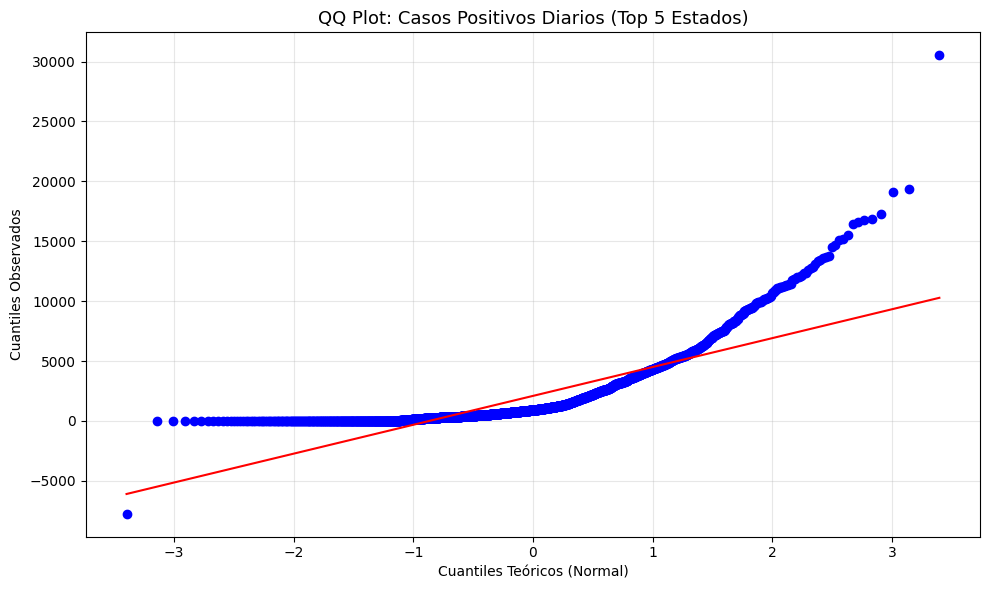

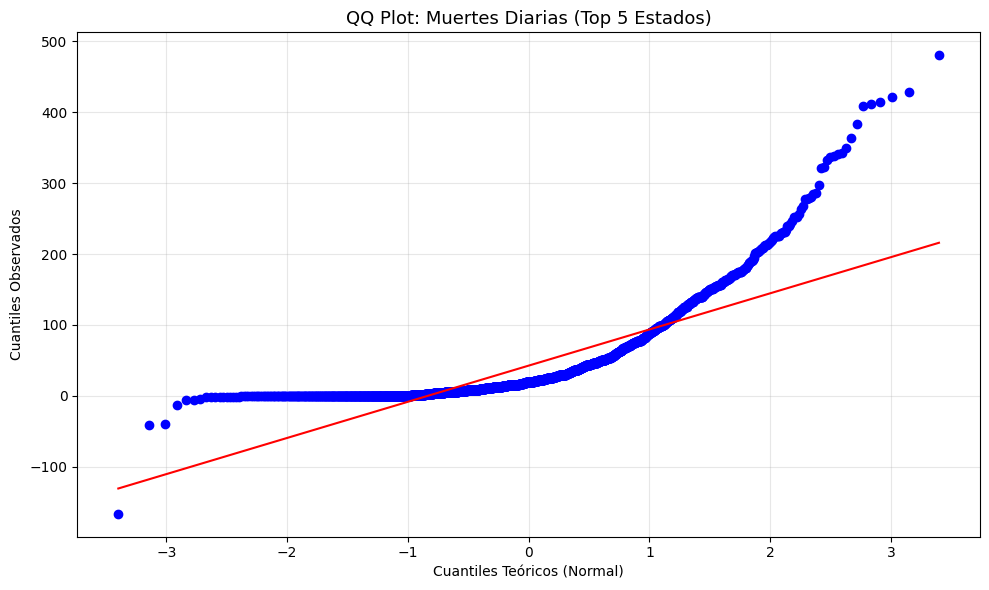

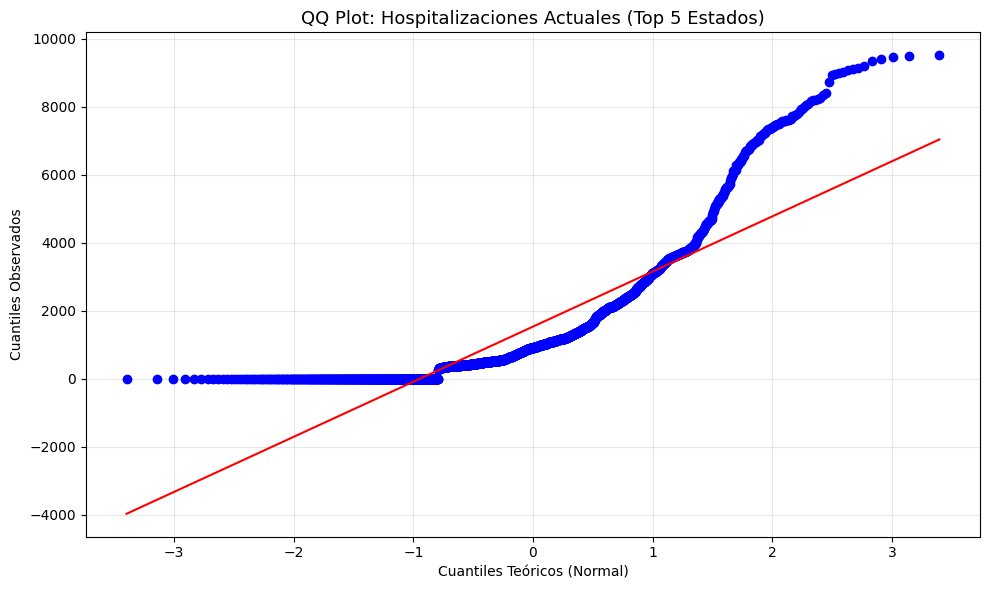

In [70]:
titulos_qq = [
    "QQ Plot: Casos Positivos Diarios",
    "QQ Plot: Muertes Diarias",
    "QQ Plot: Hospitalizaciones Actuales",
]

# Generamos los 3 QQ plots en formato vertical
for columna, titulo in zip(variables_states1, titulos_qq):
    # Filtramos valores no nulos para cada columna
    datos = df_top5[columna].dropna()
    
    plt.figure(figsize=(10, 6))
    
    # QQ plot comparando con distribución normal
    stats.probplot(datos, dist="norm", plot=plt)
    
    plt.title(f"{titulo} (Top 5 Estados)", fontsize=13)
    plt.xlabel("Cuantiles Teóricos (Normal)")
    plt.ylabel("Cuantiles Observados")
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

En el **QQ-Plot de casos nuevos diarios** los puntos se desvían drásticamente de la línea de referencia: presentan una distribución de cola hacia la derecha. La tasa de contagios no sigue una distribución normal. El disparo a la zona alta representa los picos de las olas, donde los valores observados son mucho mayores de lo que predeciría una distribución normal. 

El **QQ-Plot de incremento de fallecidos** muestra una forma de "S" distorsionada, con una separación severa en los extremos. El desvío en el extremo inferior es el reflejo de las anomalías por datos negativos que detectamos en el análisis descriptivo. El desvío superior confirma los días con mortalidad récord bajo la suposición de normalidad.

La desviación en el **QQ-Plot de hospitalizaciones** es más suave o curva, pero sigue sin alinearse con la recta: delata un comportamiento de asimetría. Dado que la ocupación hospitalaria depende del tiempo de estancia del paciente, los datos decaen lentamente, no de golpe. 

Los QQ-Plots demuestran que ninguna de las variables principales sigue una distribución normal. Esto significa que no se pueden realizar pruebas paramétricas como la T de Student o el ANOVA, ya que los datos violan el principio de normalidad.
Además, los QQ-Plots avisan de que, para que la regresión funcione, se necesita aplicar transformaciones matemáticas a las variables (como una transformación logarítmica $\log(x + 1)$ o la de Box-Cox) para "estirar" los datos y forzarlos a aproximarse a la normalidad.

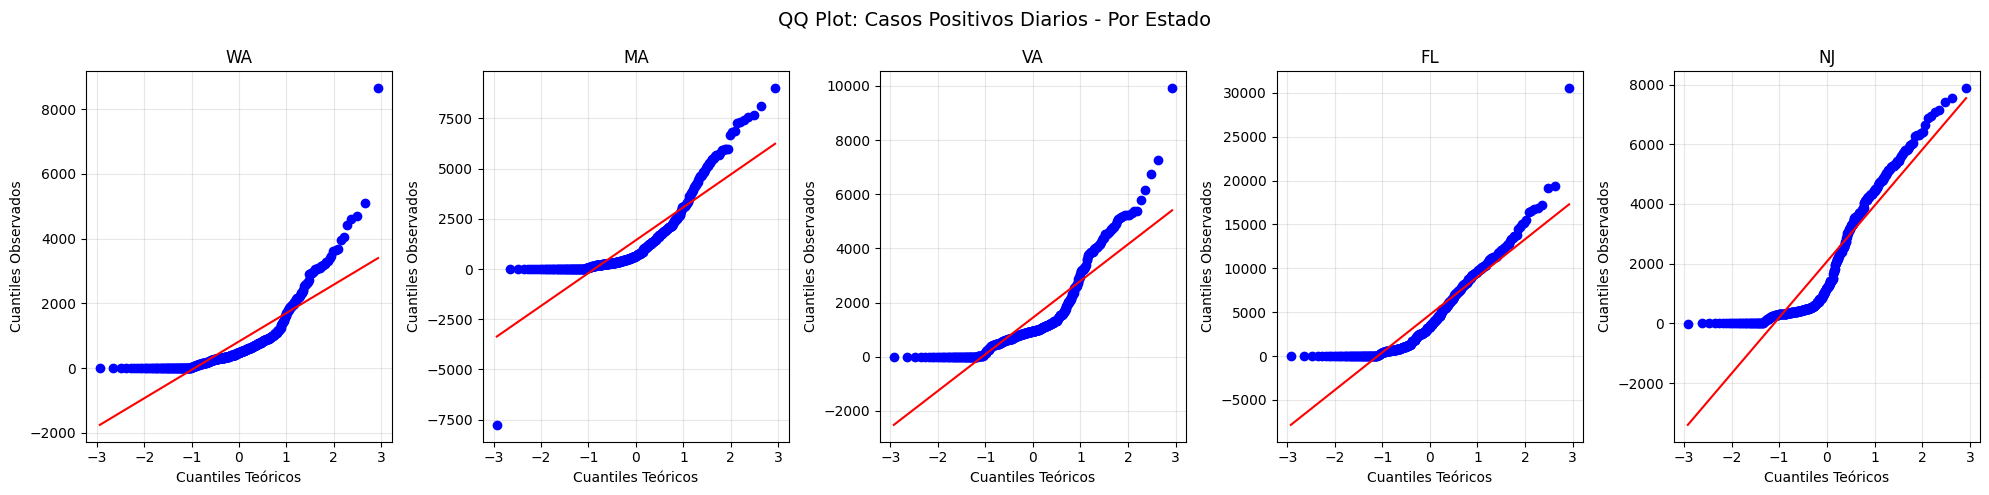

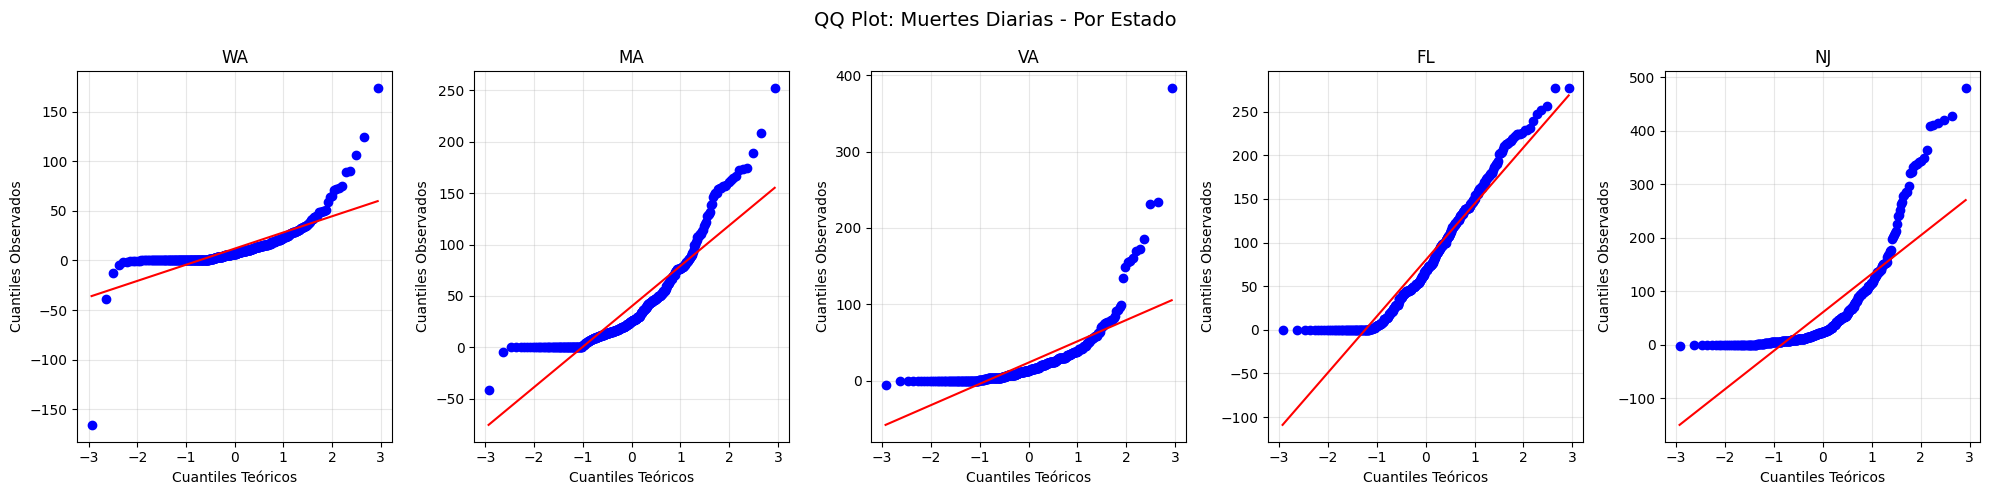

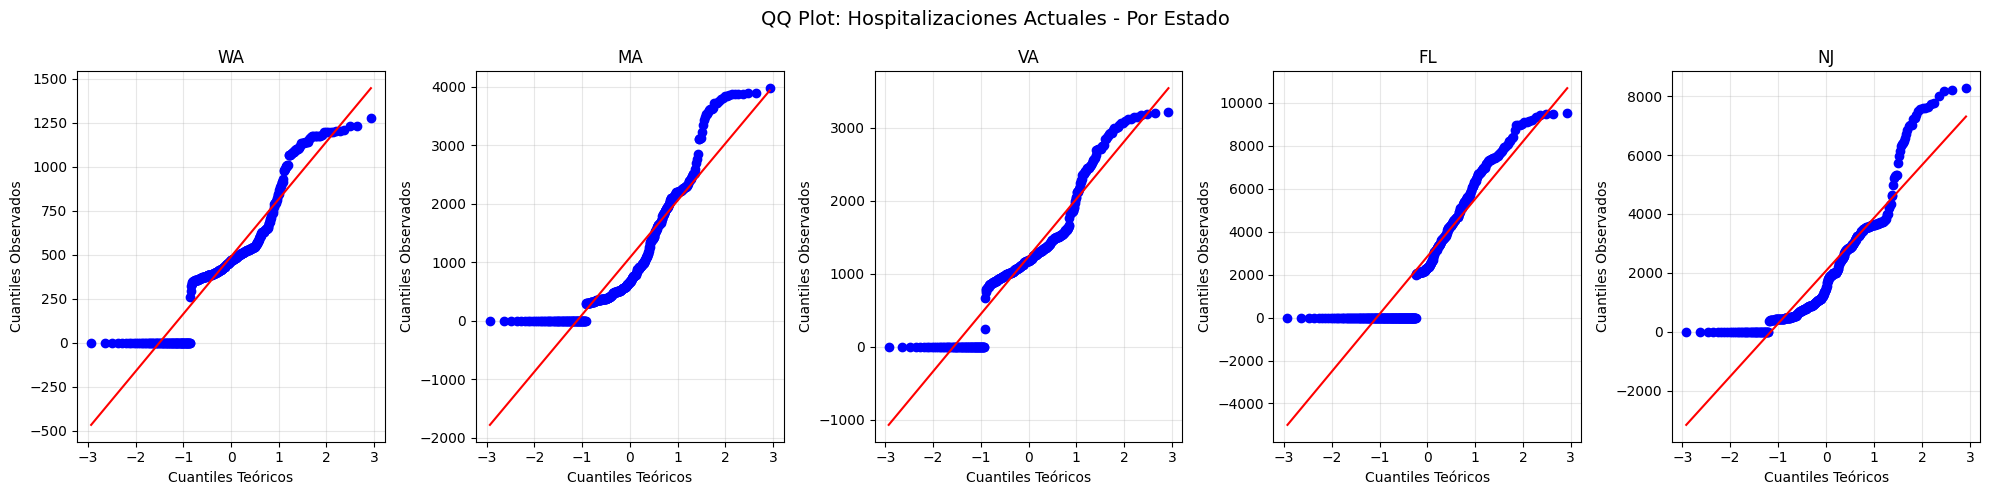

In [71]:
# QQ plots por cada estado (top 5)
for columna, titulo in zip(variables_states1, titulos_qq):
    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    fig.suptitle(f"{titulo} - Por Estado", fontsize=14)
    
    for i, estado in enumerate(top_5_frecuentes):
        # Filtrar datos del estado actual
        datos_estado = df_top5[df_top5["state"] == estado][columna].dropna()
        
        # QQ plot en el subplot correspondiente
        stats.probplot(datos_estado, dist="norm", plot=axes[i])
        axes[i].set_title(estado)
        axes[i].set_xlabel("Cuantiles Teóricos")
        axes[i].set_ylabel("Cuantiles Observados")
        axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

Ningún estado se comportó de forma "normal", porque la pandemia avanzó por pulsos locales. La base plana inicial demuestra que el virus llegó más tarde a algunas regiones, lo que rompe el supuesto de homogeneidad temporal de una distribución normal estándar.

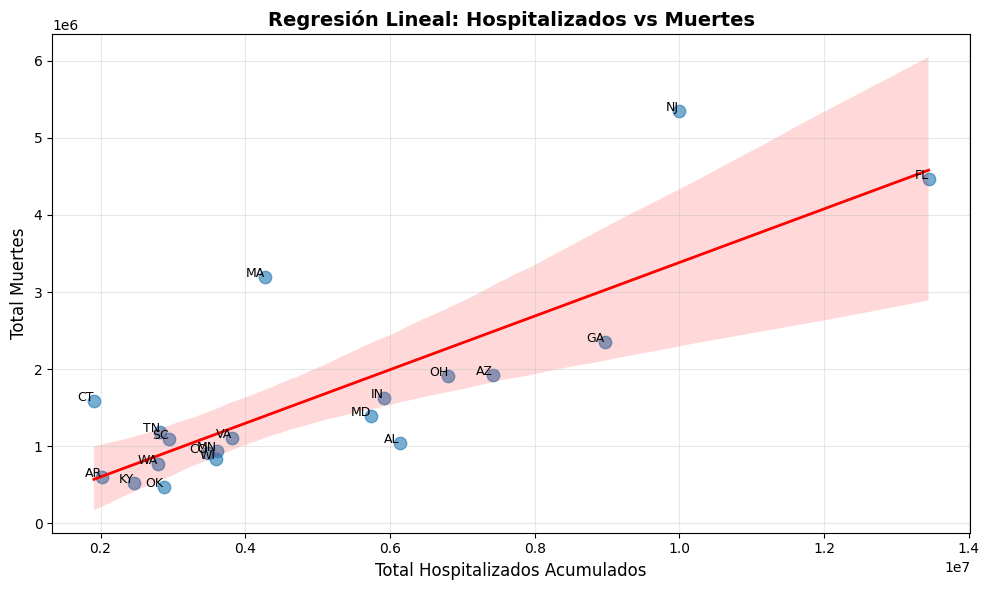

In [81]:
#Agrupar por estado
relacion_estados = df_states.groupby('state').agg({
    'hospitalizedCumulative': 'sum',
    'death': 'sum'
}).reset_index()

#Regresion Hospitalizados y muertos
plt.figure(figsize=(10, 6))

#Usar datos de los top 20 estados para mejor visualización
top20 = relacion_estados.nlargest(20, 'hospitalizedCumulative')

sns.regplot(data=top20, 
            x='hospitalizedCumulative', 
            y='death',
            scatter_kws={'alpha':0.6, 's':80},
            line_kws={'color':'red', 'linewidth':2})

#Añadir etiquetas para los puntos más grandes
for row in top20.iterrows():
    if row[1]['hospitalizedCumulative'] > 50000:  # Solo etiquetar los puntos con hospitalizaciones acumuladas mayores a 50k
        plt.text(row[1]['hospitalizedCumulative'], row[1]['death'], row[1]['state'], fontsize=9, ha='right')

plt.xlabel('Total Hospitalizados Acumulados', fontsize=12)
plt.ylabel('Total Muertes', fontsize=12)
plt.title('Regresión Lineal: Hospitalizados vs Muertes', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Vemos una relación positiva fuerte. La línea de regresión tiene una pendiente ascendiente clara, lo que confirma una intuición obvia: a mayor número de hospitalizaciones acumuladas en un estado, mayor es el número total de muertes.
La mayoría de los puntos se encuentran relativamente cerca de la línea o dentro del sombreado, lo que sugiere que la cantidad de hospitalizados es un buen predictor del número de muertes.

La banda de confianza (el sombreado rosa) se va ensanchando significativamente a medida que avanzamos hacia la derecha del eje X (valores superiores a $0.8 \times 10^7$).
Esto significa que tenemos muchos datos condensados en los estados con menos de 4 millones de hospitalizados (donde el modelo es muy preciso), pero pocos datos y mayor incertidumbre en los estados con altísimos volúmenes de hospitalización (como Florida - FL).

Al analizar los puntos, saltan a la vista tres comportamientos clave:
1. Letalidad inusualmente alta en Nueva Jersey (NJ) y Massachusetts (MA), muy por encima de la línea de regresión respecto a la tendencia general. Esto podría deberse a colapsos sanitarios tempranos, población envejecida o diferencias en la forma de registrar las muertes por estado. 
2. Letalidad inusualmente baja en Georgia (GA) y Arizona (AZ), por debajo de la línea de regresión. Tienen una cantidad alta de hospitalizados, pero la tasa de mortalidad es inferior.
3. Florida (FL) es el estado con mayor cantidad de hospitalizados del dataset. Debido a su magnitud, este único punto tiene una enorme influencia (conocida en estadística como leverage) sobre la inclinación de la línea roja.

### **2.6.8 Cálculo de la r de Pearson**

In [72]:
# 1. Asegurar que limpiamos los valores nulos en ambas variables para el análisis
df_regresion = df_top5[
    ["positiveIncrease", "hospitalizedCurrently"]
].dropna()

# 2. Calcular la r de Pearson (Manual)
r, _ = stats.pearsonr(
    df_regresion["positiveIncrease"], df_regresion["hospitalizedCurrently"]
)

# 3. Ajustar el modelo OLS (Mínimos Cuadrados Ordinarios) con tus variables
# La fórmula 'Y ~ X' significa que hospitalizedCurrently depende de positiveIncrease
modelo_covid = smf.ols(
    "hospitalizedCurrently ~ positiveIncrease", data=df_regresion
).fit()

# 4. Imprimir las verificaciones estadísticas
print(f"--- VERIFICACIÓN DE CORRELACIÓN Y DETERMINACIÓN (COVID-19) ---")
print(f"r de Pearson        : {r:.4f}")
print(f"r² (manual)         : {r**2:.4f}")
print(f"R² del modelo OLS   : {modelo_covid.rsquared:.4f}")

--- VERIFICACIÓN DE CORRELACIÓN Y DETERMINACIÓN (COVID-19) ---
r de Pearson        : 0.7555
r² (manual)         : 0.5707
R² del modelo OLS   : 0.5707


Existe una correlación fuerte entre el incremento diario de casos positivos y el número de pacientes hospitalizados. 
Este resultado confirma de manera cuantitativa que el aumento de la detección de casos se traslada de forma casi inmediata y proporcional a una presión hospitalaria. Las hospitalizaciones son reflejo directo de la velocidad de propagación. 

No obstante, hay que tener en cuenta Pearson es extremadamente sensible a los valores atípicos (outliers): los picos masivos durante los meses críticos pueden inflar artificialmente el valor de $r$.

### **2.6.9 Cálculo de las métricas principales**

In [73]:
metricas_generales = {
    'Métrica': [
        'Total Hospitalizados (Acumulativo)',
        'Total Muertes',
        'Tasa de Mortalidad Hospitalaria (%)',
        'Ratio Muertes/Hospitalizados',
        'Promedio Hospitalizados Actuales',
        'Promedio Muertes Diarias',
        'Máximo Hospitalizados Actuales',
        'Máximo Muertes Diarias'
    ],
    'Valor': [
        f"{df_states['hospitalizedCumulative'].sum():,.0f}",
        f"{df_states['death'].sum():,.0f}",
        f"{(df_states['death'].sum() / df_states['hospitalizedCumulative'].sum() * 100):.2f}%",
        f"{(df_states['death'].sum() / df_states['hospitalizedCumulative'].sum()):.4f}",
        f"{df_states['hospitalizedCurrently'].mean():,.0f}",
        f"{df_states['deathIncrease'].mean():.1f}",
        f"{df_states['hospitalizedCurrently'].max():,.0f}",
        f"{df_states['deathIncrease'].max():,.0f}"
    ]
}

df_metricas = pd.DataFrame(metricas_generales)
print("\n" + "=")
print("RELACIÓN GENERAL: HOSPITALIZADOS VS MUERTES")
print("=")
print(df_metricas.to_string(index=False))


=
RELACIÓN GENERAL: HOSPITALIZADOS VS MUERTES
=
                            Métrica       Valor
 Total Hospitalizados (Acumulativo) 114,691,525
                      Total Muertes  73,386,582
Tasa de Mortalidad Hospitalaria (%)      63.99%
       Ratio Muertes/Hospitalizados      0.6399
   Promedio Hospitalizados Actuales         993
           Promedio Muertes Diarias        24.8
     Máximo Hospitalizados Actuales      22,851
             Máximo Muertes Diarias       2,559


1. Una tasa de letalidad alta al inicio no significa mayor mortalidad del virus, sino un sesgo de selección: solo se le hacía pruebas a personas que llegaban graves al hospital. Al aumentar la capacidad de testeo, el denominador creció y normaliza la métrica.
2. Según los estándares de la OMS, una tasa de positividad superior al 5% indica que la pandemia está fuera de control. Los datos muestran que los estados operaron por encima de este umbral (20-30% durante los periodos críticos). 
3. La tasa de hospitalización permite medir el impacto clínico en el sistema sanitario. El análisis de esta métrica muestra un comportamiento descendente conforme avanza 2020 y principios de 2021. Esta bajada progresiva refleja 3 posibles factores: mejor comprensión y tratamiento del virus, cambio en el perfil demográfico de los contagiados e inicio de las campañas de vacunación.
4. La métrica de pacientes críticos mantiene una estabilidad estructural relativa. A nivel exploratorio, esto indica que la proporción de pacientes hospitalizados que se agravaba hasta necesitar cuidados intensivos se mantuvo relativamente constante.

### **3. Gráficas**

#### **3.1 Gráfica de comparación entre 2020 vs 2021**

   year  deathIncrease
0  2020         336802
1  2021         178349


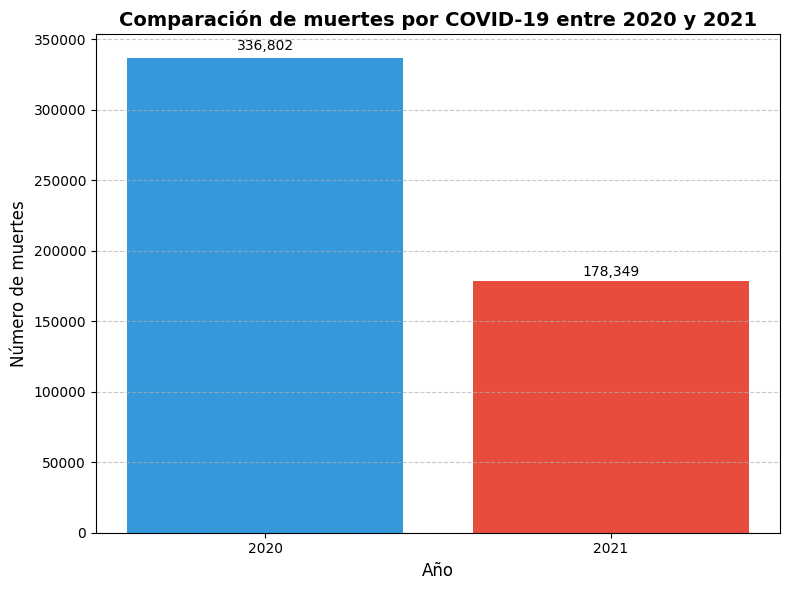

In [74]:
df_states['year'] = df_states['date'].dt.year
df_filtro = df_states[df_states['year'].isin([2020, 2021])]

muertes = df_filtro.groupby('year')['deathIncrease'].sum().reset_index()

print(muertes)

plt.figure(figsize=(8,6))
barras = plt.bar(muertes['year'].astype(str), muertes['deathIncrease'], color = ['#3498db', '#e74c3c'])
plt.title('Comparación de muertes por COVID-19 entre 2020 y 2021', fontsize=14, fontweight='bold')

plt.xlabel('Año', fontsize=12)
plt.ylabel('Número de muertes', fontsize=12)
plt.grid(axis= 'y',linestyle='--', alpha=0.7)

for bar in barras:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (yval*0.01), f'{yval:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

El gráfico muestra un descenso pronunciado en el número de muertes registradas entre ambos años, pero existe un sesgo de la recolección de datos: se dejaron de recolectar el 7 de marzo de 2021. 
Es decir: la barra de 2020 representa 10 u 11 meses de pandemia (febrero-diciembre), mientras que la barra de 2021 representa menos de 3 meses. Aun así, la reducción es de un 47%: en dos meses se produjeron la mitad de muertes que en todo el año anterior. 

### **3.2 Gráfica de los 10 estados con más muertes**

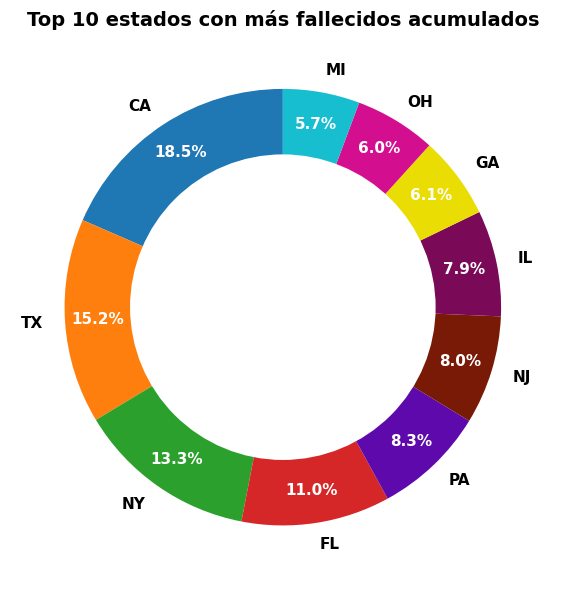

In [75]:
top_10_estados = (df_states.groupby('state')['death']
                  .max()
                  .sort_values(ascending=False)
                  .head(10))
colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', "#5e09ac", "#791a07", "#7a0958", "#e9dd04", "#d40f8f", '#17becf']

plt.figure(figsize=(6, 6))
patches, texts, autotexts = plt.pie(
    top_10_estados, 
    labels=top_10_estados.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=colores, 
    pctdistance=0.85, 
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)

for autotext in autotexts:
    autotext.set_color('white')

circulo = plt.Circle((0, 0), 0.70, fc = 'white')
fig = plt.gcf()
fig.gca().add_artist(circulo)
plt.title('Top 10 estados con más fallecidos acumulados', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

En este gráfico vemos la concentración en el "Top 4": California, Texas, Nueva York y Florida acumulan el 58% de este top 10. Esto nos habla de una enorme centralización del impacto de la pandemia en los estados más poblados del país. El resto de estados muestran porcentajes muy similares (entre 8,3 y 5,7%), lo que indica un impacto plano o estable. 

Punto a aclarar: se trata de porcentajes del subtotal sumado de estos 10 estados, no del total de muertes de todo el país. 

#### **3.3. Evolución mensual de muertes**

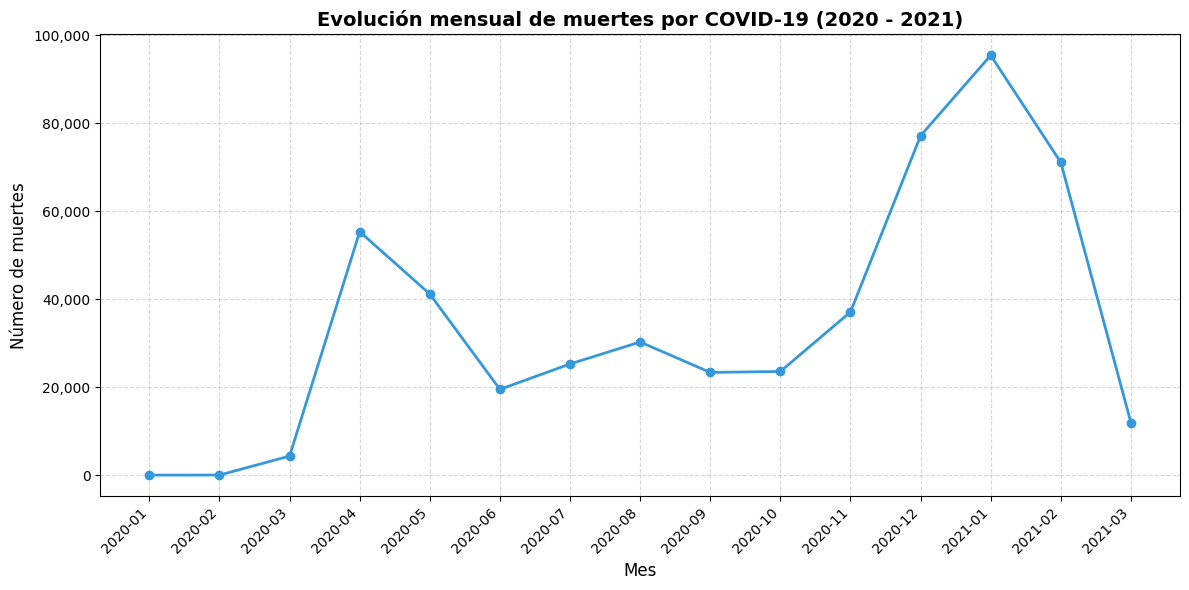

In [80]:
# Línea de muertes de cada mes
df_states['year_month'] = df_states['date'].dt.to_period('M').astype(str)


df_states['year'] = df_states['date'].dt.year
df_filtro = df_states[df_states['year'].isin([2020, 2021])]

muertes_mes = df_filtro.groupby('year_month')['deathIncrease'].sum().reset_index()
muertes_mes = muertes_mes.sort_values('year_month')

plt.figure(figsize=(12, 6))

plt.plot(muertes_mes['year_month'], muertes_mes['deathIncrease'], marker='o', color = '#3498db', linewidth = 2, markersize = 6, label = 'Muertes por mes')

plt.title('Evolución mensual de muertes por COVID-19 (2020 - 2021)', fontsize=14, fontweight='bold')
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Número de muertes', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.5)

ax = plt.gca()
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))

plt.tight_layout()
plt.show()

Este gráfico de líneas revela con precisión la naturaleza cíclica de la pandemia, pues identifica claramente dos olas principales de mortalidad: 
1. La Primera Ola sucede en la primavera de 2020, concretamente en abril, superando las 50.000 muertes mensuales. Esto coincide con el impacto inicial del virus. 
2. En el Periodo de Meseta (meses de verano - otoño de 2020), las muertes disminuyen, pero se estabilizan en un suelo alto (20.000-30.000 muertes), mostrando que el virus no dejó de circular.
3. Al inicio de la Gran Segunda Ola, durante el invierno de 2020-2021, la curva se dispara exponencialmente. El pico más alto ocurre en enero de 2021, rozando las 100.000 muertes en un solo mes. Este comportamiento es típico de los virus respiratorios, potenciando por las reuniones de fin de año y el clima invernal.

#### **3.4 Comparativa entre tasa de positividad y tasa de mortalidad**

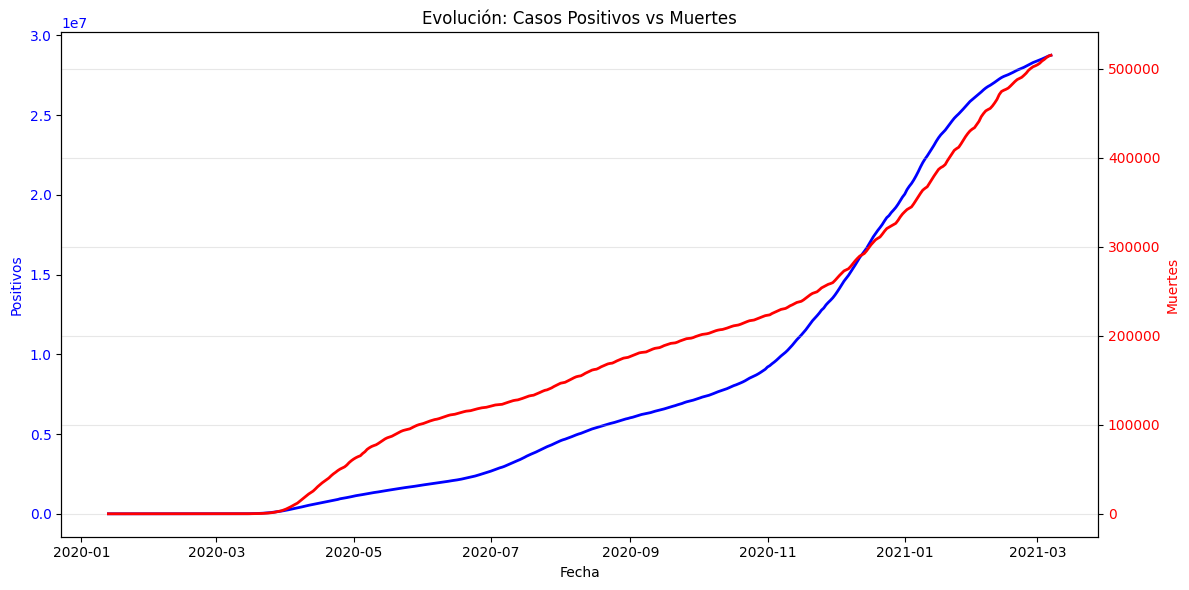

In [82]:
#Evolucion casos positivos y muertes
#Agrupamos fechas
evolucion = df_states.groupby('date')[['positive', 'death']].sum().reset_index()
evolucion = evolucion.sort_values('date')
#Tabla comparatiba
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(evolucion['date'], evolucion['positive'], 'b-', linewidth=2, label='Positivos')
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Positivos', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax2 = ax1.twinx()
ax2.plot(evolucion['date'], evolucion['death'], 'r-', linewidth=2, label='Muertes')
ax2.set_ylabel('Muertes', color='r')
ax2.tick_params(axis='y', labelcolor='r')
plt.title('Evolución: Casos Positivos vs Muertes')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Al superponer ambas escalas, el gráfico revela cómo cambió el comportamiento del virus a lo largo del tiempo. 
1. Hay un desfase inicial (entre marzo y mayo de 2020): la línea roja (muertes) sube con una pendiente bastante empinada; la línea azul (positivos) apenas se levanta. 

Al inicio de la pandemia, la capacidad de hacer pruebas diagnósticas (testeo) era muy limitada, de ahí que se detecten pocos casos positivos, pero las muertes se registran de forma más evidente. Esto distorsionaba la tasa de letalidad percibida.

2. La sincronización de las curvas entre noviembre y marzo de 2021 indica que se realizaban tests masivos (la línea azul refleja mejor la realidad de los contagios). Hay una relación directamente proporcional y constante entre el volumen de nuevos contagios y el volumen de fallecidos en las semanas siguientes.

El gráfico nos demuestra que existió una fase de desconocimiento (inicio de 2020), con una alta mortalidad y pocos casos positivos registrados, que evoluciona a una fase de control y sincronización entre los contagios y las muertes.

La relación final es de aproximadamente 1 muerte por cada 56 casos positivos ($2.85 \times 10^7 / 500,000$), lo que equivale a una letalidad cruda acumulada de alrededor del 1.75% al cierre de los datos.

### **4. Conclusión**

Este análisis exploratorio nos ha permitido entender la pandemia desde cuatro dimensiones críticas: la predictibilidad de la letalidad, las limitaciones de los datos temporales, la concentración geográfica del impacto y la evolución de la tasa de mortalidad.

A través de las visualizaciones, podemos extraer tres grandes conclusiones analíticas: 
1. El análisis demográfico (especialmente el gráfico de dona) demuestra que el impacto de la pandemia no fue homogéneo. Los volúmenes demográficos y la densidad urbana fueron los principales catalizadores de la mortalidad. 
2. La regresión lineal valida que las hospitalizaciones acumuladas son un predictor robusto del número de muertes. Sin embargo, el EDA detecta algunas desviaciones críticas en la gestión: algunos estados (como Nueva Jersey) sufrieron tasas de letalidad desproporcionadametne altas respecto al volumen de hospitalizados, mientras que Georgia y Arizona lograron mantener la mortalidad por debajo de la tendencia esperada por el modelo. 
3. Al desglosar los datos de manera mensual, logramos identificar la verdadera dinámica del virus, caracterizada por un impacto inicial agresivo y una devastadora segunda ola que alcanzó su pico en enero de 2021. 